# Week 3 — Day 1: Linear Regression Fundamentals

## Notebook Goal

In this notebook, we will begin our practical study of supervised machine
learning.

We will first understand how a supervised learning problem is structured.
Then, we will create a small controlled regression dataset and gradually build
a Linear Regression model using Scikit-learn.

The goal is not only to train a model, but also to understand:

- What the input features represent.
- What the target variable represents.
- What relationship the model is trying to learn.
- How useful information differs from random noise.
- How we can determine whether the model learned the correct relationship.

## 1. What Is Supervised Learning?

Supervised learning is a machine learning approach in which the model learns
from labeled examples.

Each example contains:

- A set of input features, usually represented by `X`.
- A known correct answer, usually represented by `y`.

The model examines many examples and attempts to learn a general relationship
between the features and the target.

After training, the learned relationship can be used to predict the target for
new observations that the model has not seen before.

### Regression and Classification

Supervised learning problems are commonly divided into two main categories:

1. **Regression**  
   The target is a continuous numeric value, such as a price, temperature,
   salary, or sales amount.

2. **Classification**  
   The target is a discrete class, such as spam or not spam, sick or healthy,
   or customer churn and no churn.

Our task in this notebook is a regression problem because the target will be a
continuous numeric value.

## 2. Importing the Core Libraries

Before creating the regression experiment, we will import the core libraries
needed to generate, organize, and visualize the data.

At this stage, we are not importing the machine learning model yet. We will
introduce each Scikit-learn component only when we reach the step that requires
it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Understanding a Linear Relationship

Linear Regression assumes that the target can be approximated using a linear
combination of the input features.

A simple linear equation can be written as:

$$
y = b + w_1x_1 + w_2x_2 + w_3x_3
$$

Where:

- \(x_1, x_2, x_3\) are the input features.
- \(w_1, w_2, w_3\) are the weights associated with the features.
- \(b\) is the intercept.
- \(y\) is the predicted target value.

Each weight determines how much its corresponding feature contributes to the
final prediction.

### A Manual Prediction Example

Before creating a complete dataset, we will calculate one prediction manually.

Suppose one observation has the following feature values:

$$
x_1 = 2,\quad x_2 = 1,\quad x_3 = 4
$$

We will apply the known weights and intercept to calculate its target value.
This small example demonstrates the exact mathematical operation performed by
a linear model when it makes a prediction.


In [2]:
sample = np.array([2.0, 1.0, 4.0])
weights = np.array([3.0, -2.0, 1.5])
intercept = 4.0

### Calculating Feature Contributions

Each feature contributes to the prediction through the multiplication of its
value by its corresponding weight.

We will first calculate these contributions separately, then add them to the
intercept to obtain the final prediction.


In [3]:
feature_contributions = sample * weights
feature_contributions

array([ 6., -2.,  6.])

In [4]:
prediction = intercept + feature_contributions.sum()
print("Feature contributions:", feature_contributions)
print("Intercept:", intercept)
print("Final prediction:", prediction)

Feature contributions: [ 6. -2.  6.]
Intercept: 4.0
Final prediction: 14.0


### Interpretation

The first feature contributed `6` to the prediction, the second feature
contributed `-2`, and the third feature contributed `6`.

After adding these contributions to the intercept of `4`, the final predicted
value was:

$$
\hat{y} = 14
$$

This is the basic prediction mechanism behind Linear Regression. A trained
model performs the same calculation, but instead of receiving predefined
weights, it learns suitable weights from the training data.


### Expressing the Same Prediction with a Dot Product

The previous prediction was calculated by multiplying each feature by its
corresponding weight and then summing the resulting contributions.

This operation can be written more compactly as a dot product:

$$
\mathbf{x} \cdot \mathbf{w}
=
x_1w_1 + x_2w_2 + x_3w_3
$$

The final linear prediction is therefore:

$$
\hat{y} = \mathbf{x} \cdot \mathbf{w} + b
$$

Using a dot product does not change the calculation. It provides a shorter and
more scalable way to perform the same operation.

In [5]:
weighted_sum = np.dot(sample, weights)
weighted_sum

np.float64(10.0)

In [6]:
dot_product_prediction = weighted_sum + intercept

print("Weighted sum:", weighted_sum)
print("Intercept:", intercept)
print("Final prediction:", dot_product_prediction)

Weighted sum: 10.0
Intercept: 4.0
Final prediction: 14.0


### Interpretation

The dot product produced a weighted sum of `10`.

After adding the intercept of `4`, the final prediction was again `14`.
Therefore, the dot-product calculation is equivalent to the earlier
feature-by-feature calculation.

This operation is fundamental to both Linear Regression and Neural Networks.
The main difference is that a neural network may repeat this operation across
many neurons and layers, usually followed by nonlinear activation functions.


## 4. From One Sample to Multiple Samples

A real machine learning dataset usually contains many observations rather than
a single sample.

The complete feature dataset is commonly represented by a matrix called `X`:

* Each row represents one observation or sample.
* Each column represents one input feature.

The same weight vector is applied to every row in the dataset. This allows a
linear model to calculate one prediction for each observation using matrix
multiplication.


In [7]:
X_small = np.array([
    [2.0, 1.0, 4.0],
    [1.0, 3.0, 2.0],
    [0.0, 2.0, 5.0],
    [3.0, 0.0, 1.0]
])
X_small

array([[2., 1., 4.],
       [1., 3., 2.],
       [0., 2., 5.],
       [3., 0., 1.]])

In [8]:
print("Shape of X_small:", X_small.shape)
print("Number of samples:", X_small.shape[0])
print("Number of features:", X_small.shape[1])

Shape of X_small: (4, 3)
Number of samples: 4
Number of features: 3


### Calculating Predictions for the Entire Dataset

Instead of calculating the prediction for each observation separately, we can
multiply the full feature matrix by the weight vector:

$$
\mathbf{X}\mathbf{w}
$$

This operation calculates the dot product between every row in
\(\mathbf{X}\) and the weight vector \(\mathbf{w}\).

The intercept is then added to every resulting weighted sum. The vector \(\mathbf{1}\) indicates that the same intercept is added to every observation:

$$
\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b\mathbf{1}
$$

The result is a vector containing one prediction for every observation.

In [9]:
weighted_sums = X_small @ weights
weighted_sums

array([10. ,  0. ,  3.5, 10.5])

In [10]:
predictions = weighted_sums + intercept
predictions

array([14. ,  4. ,  7.5, 14.5])

In [11]:
small_results = pd.DataFrame(
    X_small,
    columns=["x1", "x2", "x3"]
)
small_results["prediction"] = predictions
small_results

,x1,x2,x3,prediction
0,2.0,1.0,4.0,14.0
1,1.0,3.0,2.0,4.0
2,0.0,2.0,5.0,7.5
3,3.0,0.0,1.0,14.5


### Interpretation

The feature matrix contained four observations and three features.

Matrix multiplication applied the same weight vector to every observation,
producing one weighted sum for each row. After adding the intercept, the final
prediction vector contained four values:

$$
\hat{\mathbf{y}}
=
\begin{bmatrix}
14 \\
4 \\
7.5 \\
14.5
\end{bmatrix}
$$

This is the vectorized form of linear prediction. It performs the same
calculation used for a single observation, but processes the entire dataset at
once without requiring a separate loop for every row.

## 5. Creating a Controlled Regression Dataset

To evaluate whether Linear Regression can learn the correct relationship, we
will create a synthetic dataset using a known equation:

$$
y
=
4
+
3x_1
-
2x_2
+
1.5x_3
+
0x_4
+
0x_5
+
\varepsilon
$$

The features \(x_1\), \(x_2\), and \(x_3\) contain useful predictive
information. The features \(x_4\) and \(x_5\) have true weights of zero, so they
do not directly affect the target.

The term \(\varepsilon\) represents random noise, which makes the observations
more realistic and prevents the relationship from being perfectly predictable.

Because the true parameters are known, we can later compare them with the
parameters learned by the model.

In [12]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n_samples = 500

feature_names = [
    "x1",
    "x2",
    "x3",
    "x4_noise",
    "x5_noise"
]

true_intercept = 4.0

true_weights = np.array([
    3.0,
    -2.0,
    1.5,
    0.0,
    0.0
])

X = rng.normal(
    loc=0.0,
    scale=1.0,
    size=(n_samples, len(feature_names))
)

noise = rng.normal(
    loc=0.0,
    scale=1.0,
    size=n_samples
)

true_signal = true_intercept + X @ true_weights
y = true_signal + noise


In [13]:
data = pd.DataFrame(X, columns=feature_names)

data["true_signal"] = true_signal
data["noise"] = noise
data["target"] = y

print("X shape:", X.shape)
print("y shape:", y.shape)

data.head()

X shape: (500, 5)
y shape: (500,)


,x1,x2,x3,x4_noise,x5_noise,true_signal,noise,target
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,8.119796,0.553077,8.672873
1,-1.302180,0.127840,-0.316243,-0.016801,-0.853044,-0.636583,0.248914,-0.387670
2,0.879398,0.777792,0.066031,1.127241,0.467509,5.181656,1.008668,6.190324
3,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.753703,0.484453,-0.269249
4,-0.184862,-0.680930,1.222541,-0.154529,-0.428328,6.641084,1.217725,7.858809


## 6. Splitting the Data into Training and Test Sets

A machine learning model should not be evaluated using the same observations
that were used during training.

We will divide the dataset into:

* A training set used by the model to learn the relationship between
  \(\mathbf{X}\) and \(\mathbf{y}\).
* A test set used to evaluate the model on observations it did not see during
  training.

We will use 80% of the observations for training and reserve 20% for testing.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 5)
X_test shape: (100, 5)
y_train shape: (400,)
y_test shape: (100,)


## 7. Training the Linear Regression Model

We will now create a Linear Regression model and train it using the training
data.

During training, the model will attempt to learn an intercept and a weight for
each feature.

The model will not receive the true parameters that were used to generate the
dataset. It will receive only `X_train` and `y_train` and must estimate the
relationship from those observations.


### How Ordinary Least Squares Learns the Parameters

Scikit-learn's `LinearRegression` uses Ordinary Least Squares (OLS). OLS chooses
the intercept and feature weights that minimize the sum of squared residuals on
the training data:

$$
\min_{b,\mathbf{w}}
\sum_{i=1}^{n}
\left(
y_i - \left(b + \mathbf{x}_i^{\mathsf{T}}\mathbf{w}\right)
\right)^2
$$

In simple terms, the model selects the combination of parameters that makes the
training predictions as close as possible to the observed targets. Squaring the
residuals prevents positive and negative errors from canceling and penalizes
large errors more strongly.

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 3.09,-1.99, 1.47,-0.03, 0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.031
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[21.41,20.75,20.35,19.48,18.76]"


In [18]:
print("Learned intercept:", model.intercept_)
print("Learned weights:", model.coef_)

Learned intercept: 4.031286649050333
Learned weights: [ 3.09326653 -1.99322488  1.4704964  -0.03286039  0.03981967]


### Comparing Learned and True Parameters

Because the dataset was generated from known parameters, we can directly compare
the model's estimates with the true values.

Small differences are expected because random noise was added to the target.
The irrelevant features should receive learned weights close to zero.


In [19]:
weights_comparison = pd.DataFrame({
    "feature": feature_names,
    "true_weight": true_weights,
    "learned_weight": model.coef_
})

weights_comparison["absolute_difference"] = (
    weights_comparison["learned_weight"]
    - weights_comparison["true_weight"]
).abs()

print("True intercept:", true_intercept)
print("Learned intercept:", round(model.intercept_, 4))

weights_comparison.round(4)

True intercept: 4.0
Learned intercept: 4.0313


,feature,true_weight,learned_weight,absolute_difference
0,x1,3.0,3.0933,0.0933
1,x2,-2.0,-1.9932,0.0068
2,x3,1.5,1.4705,0.0295
3,x4_noise,0.0,-0.0329,0.0329
4,x5_noise,0.0,0.0398,0.0398


## 8. Making Predictions on Unseen Data

After training, the model can use the learned intercept and feature weights to
predict target values for new observations.

We will use the test feature matrix stored in `X_test`. These observations were
not used during training, so they provide a fair test of the model's ability to
generalize.

For each observation, the model calculates:

$$
\hat{y}
=
\hat{b}
+
\hat{w}_1x_1
+
\hat{w}_2x_2
+
\cdots
+
\hat{w}_5x_5
$$

The symbol \(\hat{y}\) represents the model's predicted target value, while
\(y\) represents the actual target value.

In [20]:
y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))
print("First five predictions:", y_pred[:5])

Number of predictions: 100
First five predictions: [-2.82533283  8.91382166  6.93896997  7.36804582  4.82618609]


In [21]:
prediction_results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

prediction_results["error"] = (
    prediction_results["actual"]
    - prediction_results["predicted"]
)

prediction_results.head(10).round(3)

,actual,predicted,error
0,-2.085,-2.825,0.741
1,8.881,8.914,-0.033
2,6.932,6.939,-0.007
3,6.805,7.368,-0.563
4,6.048,4.826,1.221
5,3.401,3.958,-0.557
6,6.690,7.343,-0.653
7,2.465,3.039,-0.574
8,-5.184,-3.506,-1.678
9,0.902,2.106,-1.203


## 9. Evaluating Regression Performance

Inspecting individual predictions is useful, but we also need numerical metrics
that summarize the model's performance across the complete test set.

We will calculate three common regression metrics:

### Mean Squared Error

The Mean Squared Error calculates the average squared difference between the
actual and predicted values:

$$
\mathrm{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i - \hat{y}_i\right)^2
$$

Squaring the errors prevents positive and negative errors from canceling each
other and gives larger errors a stronger penalty. Lower MSE values indicate
better performance.

### Root Mean Squared Error

The Root Mean Squared Error is the square root of the MSE:

$$
\mathrm{RMSE}
=
\sqrt{\mathrm{MSE}}
$$

RMSE is easier to interpret because it is expressed in the same units as the
target variable. Lower RMSE values indicate better predictions.

### Coefficient of Determination

The coefficient of determination, \(R^2\), measures how much of the variation
in the target variable is explained by the model:

$$
R^2
=
1
-
\frac{
\sum_{i=1}^{n}
\left(y_i - \hat{y}_i\right)^2
}{
\sum_{i=1}^{n}
\left(y_i - \bar{y}\right)^2
}
$$

An \(R^2\) value close to \(1\) indicates strong performance. A value close to
\(0\) means that the model performs similarly to predicting the mean of the
target variable, while a negative value means that it performs worse than that
simple baseline.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

Test MSE:  0.8794
Test RMSE: 0.9378
Test R²:   0.9423


### Checking Training and Test Performance

A model should perform well not only on the training data but also on unseen test
data. Similar training and test scores suggest that the model learned a
generalizable relationship rather than memorizing the training observations.


In [23]:
y_train_pred = model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

performance_comparison = pd.DataFrame({
    "dataset": ["Training", "Test"],
    "RMSE": [train_rmse, rmse],
    "R²": [train_r2, r2]
})

performance_comparison.round(4)


,dataset,RMSE,R²
0,Training,1.0250,0.9316
1,Test,0.9378,0.9423


### Comparing the Model with a Baseline

A metric is more meaningful when it is compared with a simple reference model.

The baseline ignores all features and predicts the mean of `y_train` for every
test observation. A useful regression model should perform substantially better
than this mean-prediction baseline.


In [24]:
baseline_value = y_train.mean()

baseline_predictions = np.full(
    shape=y_test.shape,
    fill_value=baseline_value
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline prediction: {baseline_value:.4f}")
print(f"Baseline RMSE:       {baseline_rmse:.4f}")
print(f"Baseline R²:         {baseline_r2:.4f}")

Baseline prediction: 3.8422
Baseline RMSE:       3.9041
Baseline R²:         -0.0001


## 10. Residual Diagnostics

A residual is the difference between an actual target value and the model's
prediction:

$$
e_i = y_i - \hat{y}_i
$$

Residual diagnostics help us determine whether the model's errors appear
random or whether they contain a systematic pattern.

A well-behaved Linear Regression model should generally show:

- Predicted values close to the actual values.
- Residuals distributed around zero.
- No strong curved or systematic pattern in the residual plot.
- No small group of extremely large errors.

In [25]:
residuals = y_test - y_pred

print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Mean residual: 0.2257193368015966
Residual standard deviation: 0.9101965369388897


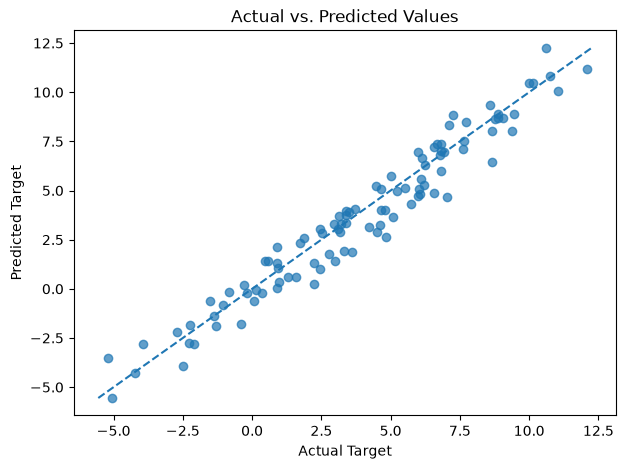

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.7)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs. Predicted Values")
plt.show()

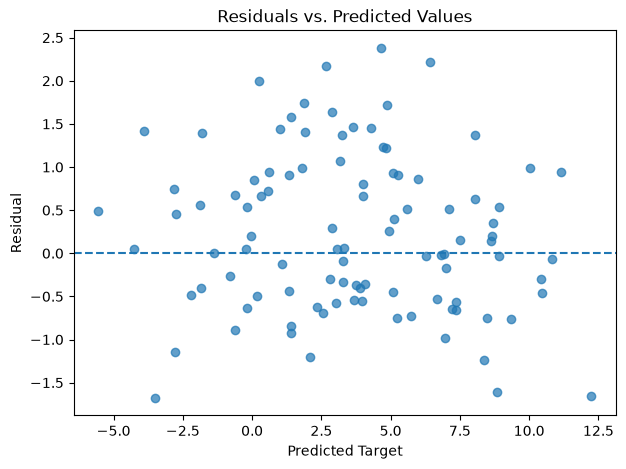

In [27]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Target")
plt.ylabel("Residual")
plt.title("Residuals vs. Predicted Values")
plt.show()

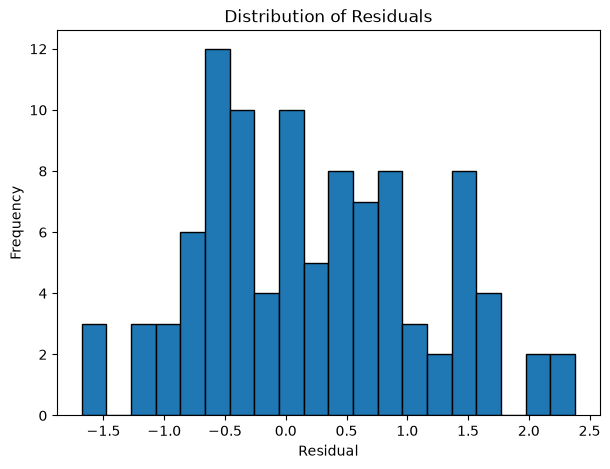

In [28]:
plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

### Interpretation of the Diagnostic Plots

The actual-versus-predicted points lie close to the diagonal reference line,
which indicates that the predictions closely follow the observed targets.

The residual plot shows errors scattered on both sides of zero without a clear
curved or systematic pattern. The residual histogram is also centered near
zero. Together, these plots support the use of a linear model for this
controlled dataset.

## 11. Final Conclusion

The Linear Regression model successfully recovered the underlying relationship
used to generate the synthetic dataset.

The learned weights for \(x_1\), \(x_2\), and \(x_3\) were close to their true
values of \(3\), \(-2\), and \(1.5\). The learned weights for the irrelevant
features \(x_4\) and \(x_5\) remained close to zero.

On the unseen test set, the model achieved an RMSE of approximately \(0.94\)
and an \(R^2\) score of approximately \(0.94\). It also performed substantially
better than the mean-prediction baseline. The training and test scores were
similar, providing no evidence of meaningful overfitting in this experiment.

These results demonstrate that Linear Regression learned the true signal in
the data while being unable to predict the intentionally added random noise
perfectly.
